# 03 — Neural preprocessing and trial matrix construction

I apply cell-level quality control, rolling baseline correction, z-score normalization, and natural movie trial alignment. The main output is a `[repeat, cell, movie_frame]` tensor saved as HDF5.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from v1_manifold.config import load_config, get_paths, set_global_seed
from v1_manifold.visualization import set_publication_style, save_figure
from v1_manifold.utils import save_table

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg["paths"]["root"] = str(ROOT)
paths = get_paths(cfg)
set_global_seed(cfg["project"]["random_seed"])
set_publication_style()
print(f"Project root: {ROOT}")

Project root: c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies


In [2]:
import pandas as pd
from v1_manifold.data_access import get_boc, get_experiment_data, extract_dff_and_metadata, get_stimulus_table
from v1_manifold.preprocessing import rolling_quantile_baseline, zscore_cells, quality_filter_cells, build_trial_tensor, save_trial_tensor_h5, repeat_average_population_matrix

experiments = pd.read_csv(paths.external_metadata)
experiment_id = int(experiments.iloc[0]["id"])
boc = get_boc(paths.allen_manifest)
data_set = get_experiment_data(boc, experiment_id)
cell_meta, dff, timestamps = extract_dff_and_metadata(data_set)
prep = cfg["preprocessing"]

keep, qc = quality_filter_cells(dff, prep["max_nan_fraction"], prep["min_snr"], prep["min_mean_dff"])
save_table(qc, paths.tables_dir / f"03_cell_quality_experiment_{experiment_id}.csv")
print(f"Retained {keep.sum()} / {len(keep)} cells")
qc.describe()

c:\Users\Peter\.neuro\Lib\site-packages\allensdk\core\brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Retained 163 / 164 cells


,cell_index,nan_fraction,mean_dff,snr
count,164.00000,164.0,164.000000,164.000000
mean,81.50000,0.0,0.016212,3.627207
std,47.48684,0.0,0.038444,3.573333
min,0.00000,0.0,0.000956,2.439679
25%,40.75000,0.0,0.002525,2.581325
50%,81.50000,0.0,0.004870,2.705233
75%,122.25000,0.0,0.013114,3.055516
max,163.00000,0.0,0.318915,30.179397


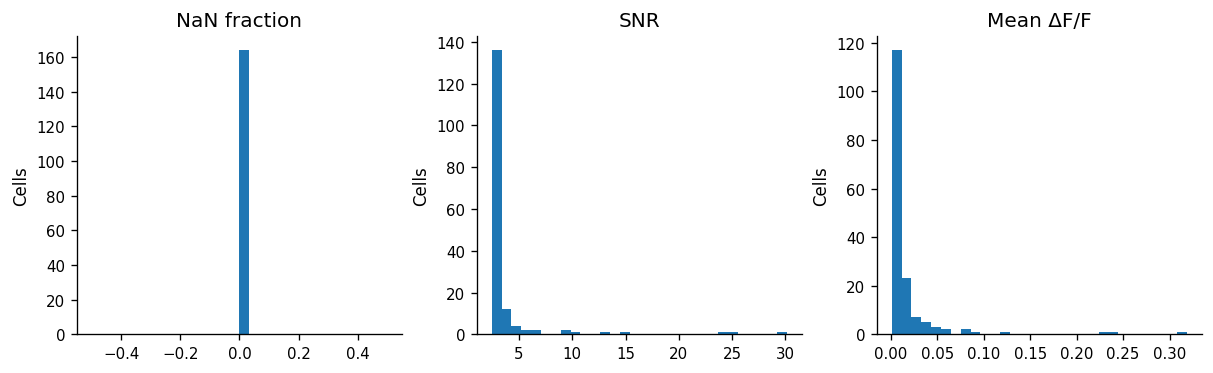

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].hist(qc["nan_fraction"], bins=30)
axes[0].set_title("NaN fraction")
axes[1].hist(qc["snr"], bins=30)
axes[1].set_title("SNR")
axes[2].hist(qc["mean_dff"], bins=30)
axes[2].set_title("Mean ΔF/F")
for ax in axes:
    ax.set_ylabel("Cells")
save_figure(fig, paths.figures_dir / "03_cell_quality_distributions.png")
plt.show()

In [5]:
dff_kept = dff[keep]
cell_meta_kept = cell_meta.loc[keep].reset_index(drop=True) if len(cell_meta) == len(keep) else cell_meta

corrected = rolling_quantile_baseline(
    dff_kept,
    prep["rolling_window"],
    prep["baseline_quantile"],
)

prep["zscore_eps"] = 1e-6

z = zscore_cells(corrected, prep["zscore_eps"])

stim = get_stimulus_table(data_set, prep["stimulus_name"])

tensor, stim_aug = build_trial_tensor(
    z,
    stim,
    prep["expected_movie_frames"],
    prep["max_repeats"],
    prep["response_aggregation"],
)

R = repeat_average_population_matrix(tensor)

out_path = paths.interim_dir / f"session_{experiment_id}_{prep['stimulus_name']}_tensor.h5"

save_trial_tensor_h5(
    out_path,
    tensor,
    stim_aug,
    cell_metadata=cell_meta_kept,
    attrs=experiments.iloc[0].to_dict(),
)

print(f"Saved trial tensor: {out_path}")
print("tensor shape:", tensor.shape, "repeat-average matrix:", R.shape)

Saved trial tensor: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\interim\session_500855614_natural_movie_one_tensor.h5
tensor shape: (10, 163, 900) repeat-average matrix: (900, 163)


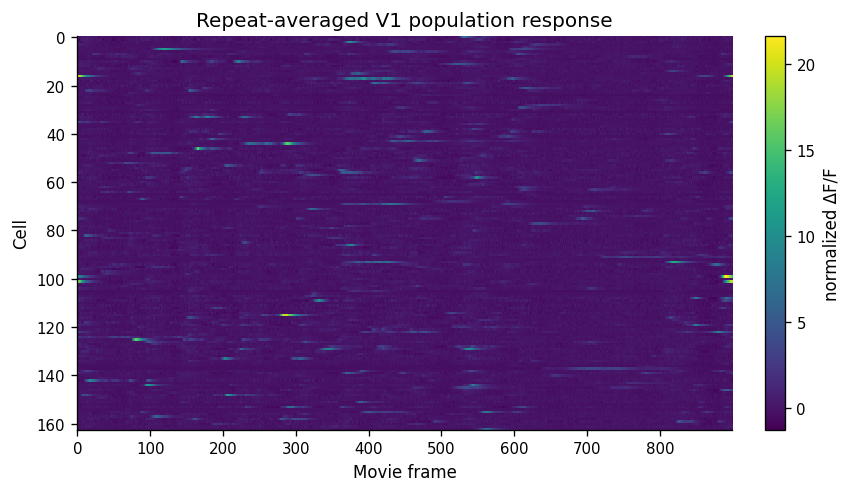

In [6]:
from v1_manifold.visualization import plot_population_heatmap

fig = plot_population_heatmap(R, title="Repeat-averaged V1 population response")
save_figure(fig, paths.figures_dir / "03_population_activity_heatmap.png")
plt.show()

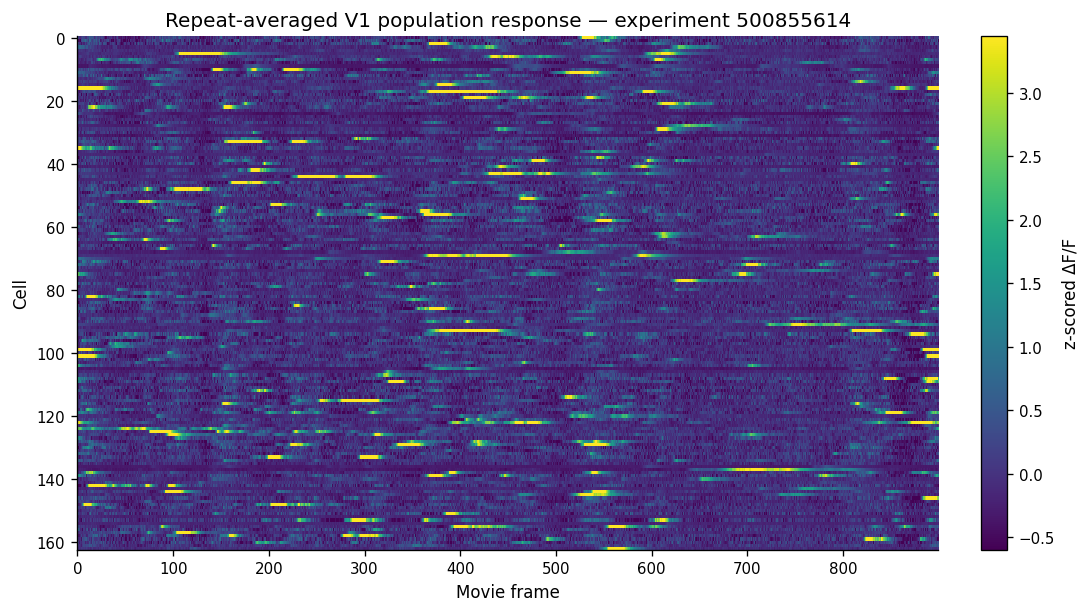

In [7]:
from v1_manifold.visualization import plot_population_heatmap
import numpy as np

# R has shape: movie frames × cells
R_plot = R.copy()

# Robust clipping for visualization only.
# This does not alter the saved tensor or downstream analysis.
vmin, vmax = np.nanpercentile(R_plot, [1, 99])

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    R_plot.T,
    aspect="auto",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
)

ax.set_xlabel("Movie frame")
ax.set_ylabel("Cell")
ax.set_title(f"Repeat-averaged V1 population response — experiment {experiment_id}")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("z-scored ΔF/F")

save_figure(
    fig,
    paths.figures_dir / f"03_population_activity_heatmap_experiment_{experiment_id}.png",
)

plt.show()